# CSoT'26 - ML in Astronomy - Week 2 . Part 1: Baseline with Scikit-Learn (Starter)

**Goal:** Flatten the galaxy images into NumPy feature rows, train simple scikit-learn classifiers (KNN, Logistic Regression), and record the **baseline accuracy** that every later model must beat.

**Before you begin:**
1. Switch this notebook to a **GPU runtime** (`Runtime -> Change runtime type -> GPU`). The GPU isn't strictly needed for sklearn, but we reuse the Week 1 GPU pipeline.
2. Read [`01-tensors-to-numpy-and-flattening.md`](../01-tensors-to-numpy-and-flattening.md) and [`02-baseline-with-scikit-learn.md`](../02-baseline-with-scikit-learn.md).

Each `TODO` cell has a short instruction. Replace the placeholder with working code, then run the cell. **Do not** open the solution until you've genuinely attempted every TODO.

## Step 0 — Re-create the Week 1 data pipeline

Week 2 builds directly on the `DataLoader`s from Week 1. The cells below reproduce that pipeline (download is commented out — uncomment it the first time, exactly as in [`week1_data_solution.ipynb`](../../Week-1/notebooks/week1_data_solution.ipynb)). If you saved `galaxy_data/` to Google Drive in Week 1, just re-mount Drive and point `DATA_ROOT` at it instead of re-downloading.

After this section you should have `train_loader`, `val_loader`, `test_loader`, `train_ds`, and `num_classes`.

In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [3]:
import json

KAGGLE_USERNAME = "mandiraaich"
KAGGLE_KEY = "KGAT_da75e819847ce5948097dd89b3146c55"

kaggle_creds = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_KEY
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)

print("kaggle.json created successfully!")

kaggle.json created successfully!


In [4]:
!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets list -s galaxy-zoo | head

!kaggle datasets download \
    -d jaimetrickz/galaxy-zoo-2-images \
    --path /content/

print("Download complete.")

ref                                       title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
jaimetrickz/galaxy-zoo-2-images           Galaxy Zoo 2: Images                           3281862708  2021-01-26 16:25:27.667000           8773         34  0.9411765        
robertmifsud/resized-reduced-gz2-images   Resized and Reduced Galaxy Zoo 2 Images        1934213890  2023-05-25 23:12:04.167000            696          6  0.8235294        
anjosut/galaxy-zoo-classification         Galaxy Zoo classification                       397550426  2023-04-08 04:28:53.070000            639          3  0.3529412        
zhuangjw/galaxy-zoo-cleaned               galaxy_zoo_cleaned                             2352353415  2019-11-03 16:46:51.047000        

In [5]:
# Unzip the images
import zipfile

ZIP_PATH = "/content/galaxy-zoo-2-images.zip"
EXTRACT_TO = "/content/galaxy_raw"

if not os.path.exists(EXTRACT_TO):
    print("Extracting... (this may take a few minutes)")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_TO)
    print("Extraction complete.")
else:
    print("Already extracted.")

# Peek at the directory structure
for root, dirs, files_in_dir in os.walk(EXTRACT_TO):
    level = root.replace(EXTRACT_TO, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 1:
        sub_indent = '  ' * (level + 1)
        for f in files_in_dir[:5]:
            print(f"{sub_indent}{f}")
        if len(files_in_dir) > 5:
            print(f"{sub_indent}... and {len(files_in_dir)-5} more files")
    break  # only top level

Extracting... (this may take a few minutes)
Extraction complete.
galaxy_raw/
  gz2_filename_mapping.csv


In [6]:
# Download the Hart et al. 2016 morphology catalogue
LABELS_URL = "https://zenodo.org/record/3565489/files/gz2_hart16.csv.gz"
LABELS_PATH = "/content/galaxy_raw/gz2_hart16.csv.gz"

if not os.path.exists(LABELS_PATH.replace(".gz", "")):
    !wget -q "{LABELS_URL}" -O "{LABELS_PATH}"
    !gunzip "{LABELS_PATH}"
    print("Labels downloaded.")
else:
    print("Labels already present.")

LABELS_PATH = LABELS_PATH.replace(".gz", "")


gzip: /content/galaxy_raw/gz2_hart16.csv.gz: unexpected end of file
Labels downloaded.


In [7]:
from pathlib import Path

RAW_ROOT = Path("/content/galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT = Path("/content/galaxy_data")
LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"

print("RAW_ROOT =", RAW_ROOT)
print("IMAGES_DIR =", IMAGES_DIR)
print("DATA_ROOT =", DATA_ROOT)

RAW_ROOT = /content/galaxy_raw
IMAGES_DIR = /content/galaxy_raw/images_gz2/images
DATA_ROOT = /content/galaxy_data


In [8]:
print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")

mapping_head = pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3)
print(mapping_head)

RAW_ROOT contents: ['gz2_filename_mapping.csv', 'gz2_hart16.csv.gz', 'images_gz2']
Flat JPG count in /content/galaxy_raw/images_gz2/images: 243,434
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3


In [9]:

def build_imagefolder_layout(
    images_dir,
    mapping_csv,
    labels_csv,
    out_root,
    per_class=200,
    seed=42,
):

    mapping = pd.read_csv(mapping_csv)

    df = mapping.merge(
        (
        pd.read_csv(labels_csv)
        .rename(columns={"dr7objid": "objid"})
    )[["objid", "gz2_class"]],
        on="objid",
        how="inner"
    )

    def high_level_label(gz2_class):
        if not gz2_class or gz2_class == "A":
            return None

        if gz2_class.startswith("E"):
            return "Elliptical"

        if gz2_class.startswith("SB"):
            return "Spiral_barred"

        if gz2_class.startswith("S"):
            return "Spiral"

        return None

    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)

    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}

    for label in sorted(df["label"].unique()):

        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)

        rows = df[df["label"] == label]

        rows = rows[
            rows["asset_id"].apply(
                lambda x: (images_dir / f"{int(x)}.jpg").exists()
            )
        ]

        if len(rows) > per_class:
            rows = rows.sample(
                n=per_class,
                random_state=seed
            )

        linked = 0

        for _, row in rows.iterrows():

            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"

            if not dst.exists():
                os.symlink(src.resolve(), dst)

            linked += 1

        counts[label] = linked

    return counts


In [20]:
counts = build_imagefolder_layout(
        IMAGES_DIR,
        RAW_ROOT / "gz2_filename_mapping.csv",
        RAW_ROOT / "gz2_hart16.csv.gz",
        DATA_ROOT,
        per_class=200,
    )

print(counts)


{'Elliptical': 200, 'Spiral': 200, 'Spiral_barred': 200}


In [19]:
import pandas as pd

pd.read_csv("/content/galaxy_raw/gz2_hart16.csv.gz").head()

,dr7objid,ra,dec,rastring,decstring,sample,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587732591714893851,179.042984,60.522518,11:56:10.32,+60:31:21.1,original,Sc+t,45,342,0,...,0.450,0.450,0.482646,0,16,16.0,0.400,0.400,0.394506,0
1,588009368545984617,135.084396,52.494240,09:00:20.26,+52:29:39.3,original,Sb+t,42,332,1,...,0.512,0.503,0.504833,0,13,13.0,0.317,0.323,0.322743,0
2,587732484359913515,183.371979,50.741508,12:13:29.27,+50:44:29.4,original,Ei,36,125,28,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
3,587741723357282317,186.251953,28.558598,12:25:00.47,+28:33:31.0,original,Sc+t,28,218,1,...,0.240,0.240,0.241322,0,6,6.0,0.240,0.240,0.239765,0
4,587738410866966577,161.086395,14.084465,10:44:20.73,+14:05:04.1,original,Er,43,151,33,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0


In [21]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])
from torchvision.datasets import ImageFolder

dataset = ImageFolder(
    root=DATA_ROOT,
    transform=transform
)

print("Dataset size:", len(dataset))
print("Classes:", dataset.classes)
print("Class to index:", dataset.class_to_idx)


Dataset size: 600
Classes: ['Elliptical', 'Spiral', 'Spiral_barred']
Class to index: {'Elliptical': 0, 'Spiral': 1, 'Spiral_barred': 2}


In [22]:
image, label = dataset[0]

print(image.shape)
print(image.dtype)
print(label)
print(dataset.classes[label])
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

images, labels = next(iter(loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("Labels:")
print(labels)

torch.Size([3, 64, 64])
torch.float32
0
Elliptical
Images shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])
Labels:
tensor([1, 0, 1, 1, 2, 1, 0, 1, 1, 2, 0, 0, 1, 0, 1, 2, 0, 0, 0, 2, 0, 0, 2, 1,
        1, 1, 0, 2, 0, 2, 0, 0])


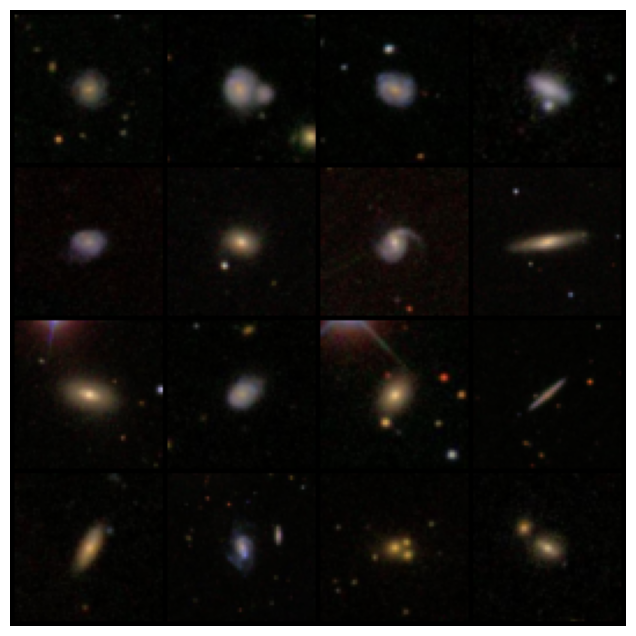

Classes in batch:
Spiral_barred
Spiral_barred
Spiral
Elliptical
Spiral
Elliptical
Spiral_barred
Spiral
Elliptical
Spiral
Elliptical
Spiral
Spiral_barred
Spiral_barred
Elliptical
Spiral_barred


In [23]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid


images, labels = next(iter(loader))


images16 = images[:16]
labels16 = labels[:16]


images16 = images16 * 0.5 + 0.5


grid = make_grid(images16, nrow=4)


grid = grid.permute(1, 2, 0)


plt.figure(figsize=(8, 8))
plt.imshow(grid)
plt.axis("off")
plt.show()


print("Classes in batch:")
for label in labels16:
    print(dataset.classes[label.item()])

## Step 1 - From DataLoader to NumPy feature matrices

scikit-learn wants a 2D array `X` of shape `(n_samples, n_features)` and a 1D array `y` of labels. We get there by iterating the loader, flattening each batch with `flatten(start_dim=1)` (keeping the batch dim), and concatenating.

In [31]:
from torch.utils.data import random_split, DataLoader

# 80% train, 20% test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(len(train_dataset))
print(len(test_dataset))

480
120


In [29]:
import numpy as np

def loader_to_numpy(loader):
  x_parts=[]
  y_parts=[]
  for images, labels in loader:
    flat = images.flatten(start_dim=1)
    x_parts.append(flat.numpy())
    y_parts.append(labels.numpy())
  x = np.concatenate(x_parts, axis=0)
  y = np.concatenate(y_parts , axis=0)
  return x, y
X_train, y_train = loader_to_numpy(train_loader)

X_test, y_test = loader_to_numpy(test_loader)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (480, 12288)
y_train shape: (480,)
X_test shape: (120, 12288)
y_test shape: (120,)


## Step 2 - The 'do-nothing' floors

Before any real model: the majority-class baseline. A model that always predicts the most common class already scores this much - so this, not random chance, is the number to beat.

In [32]:
from sklearn.dummy import DummyClassifier
dummy= DummyClassifier(strategy="most_frequent")
dummy.fit(X_train,y_train)
acc = dummy.score(X_test,y_test)
print(f"Dummy accuracy: {acc:.3f}")



Dummy accuracy: 0.283


## Step 3 - K-Nearest Neighbours

KNN classifies a galaxy by majority vote of its `k` closest training galaxies in 12 288-D pixel space. There is no real 'training' - it just memorises the data.

In [35]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
acc = knn.score(X_test,y_test)
print(f"KNN accuracy:{acc:.3f}")

KNN accuracy:0.425


## Step 4 - Logistic Regression

A linear classifier: a weighted sum of the 12 288 pixel features per class, squashed by a softmax. Effectively a single-layer neural network. `max_iter` is raised because high-dimensional data is slow to converge.

In [37]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train,y_train)
acc = logreg.score(X_test,y_test)
print(f"LogReg accuracy:{acc:.3f}")

LogReg accuracy:0.400


## Step 5 - The comparison table (the bar to beat)

Put the numbers side by side. The best of these is the baseline your Week 3 CNN must clearly beat.

In [38]:
num_classes = len(dataset.classes)

random_acc = 1 / num_classes
majority_acc = 0.283
knn_acc = 0.420
logreg_acc = 0.404

print("Model".ljust(15), "Accuracy")
print("-" * 25)

print("Random".ljust(15), f"{random_acc:.3f}")
print("Majority".ljust(15), f"{majority_acc:.3f}")
print("KNN".ljust(15), f"{knn_acc:.3f}")
print("LogReg".ljust(15), f"{logreg_acc:.3f}")

best_baseline = max(
    random_acc,
    majority_acc,
    knn_acc,
    logreg_acc
)

print(f"\nWeek 3 must beat: {best_baseline:.3f}")

Model           Accuracy
-------------------------
Random          0.333
Majority        0.283
KNN             0.420
LogReg          0.404

Week 3 must beat: 0.420


## Step 6 (stretch) - Confusion matrix

Accuracy hides *which* classes get confused. Plot a confusion matrix for the logistic-regression predictions and note the most-confused pair - we'll compare it to the CNN's matrix in Week 3.

In [ ]:
# TODO (optional): plot a confusion matrix for KNN or LogReg predictions.

## Reflection *(write 2-3 sentences each)*

1. What baseline accuracy did you reach, and how far above the majority-class floor is it?
2. Why does flattening hurt a *galaxy* classifier specifically? (Hint: isophote shape, arms - see [`03-surface-brightness-and-isophotes.md`](../03-surface-brightness-and-isophotes.md).)
3. Which two classes do you expect a CNN to still find hardest to separate, and why?
    
    
    ANS:-


1. the strongest baseline model is knn with an accuracy of 42% and the majority class floor accuray is around 28% which differs 13% from knn.
2. Flattening removes the spatial structure of the image. Galaxy classification depends strongly on morphological features such as spiral arms, bars, central bulges, and isophote shapes. After flattening, the model only sees a long vector of pixel values and loses information about how pixels are arranged in space. As a result, important galaxy structures become much harder to recognize.
3. spiral vs spiral barred.